---
title: Evidenciando el error de generalización de una red neuronal
subject: Aprendizaje Profundo
subtitle: 
short_title: Error de Generalización
authors:
  - name: Jorge Anais
    orcid: 0000-0001-9051-1338
    email: jrganais@gmail.com
license: MIT
---

**Objetivo**: Evaluar de manera práctica el fenómeno de la generalización en redes neuronales para comprender cómo se comportan ante datos nuevos.

# 1. Importación de librerías y configuración

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [ ]:
EPOCAS      = 15
BATCH_SIZE  = 128
TASA_APREN  = 0.001

# Usamos GPU si está disponible, si no CPU
dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {dispositivo}")

Usando: cuda


## 2. Datos CIFAR 10

CIFAR-10 tiene 60 000 imágenes de 32×32 píxeles en 10 clases. Cada imagen tiene 3 canales (RGB) → 3 × 32 × 32 = 3072 valores de entrada.

In [ ]:
# Normalizamos los píxeles al rango [-1, 1]
transformacion = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),   # media por canal
                         (0.5, 0.5, 0.5))   # desviación estándar por canal
])

# Descarga automática (solo la primera vez)
train_dataset = torchvision.datasets.CIFAR10(
    root="./datos", train=True,  download=True, transform=transformacion
)
test_dataset = torchvision.datasets.CIFAR10(
    root="./datos", train=False, download=True, transform=transformacion
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

clases = ["avión", "auto", "pájaro", "gato", "ciervo",
          "perro", "rana", "caballo", "barco", "camión"]

Mostramos 40 imágenes aleatorias del conjunto de entrenamiento,
organizadas en una grilla de 5 filas × 8 columnas.

Las imágenes fueron normalizadas al rango [-1, 1] para la red.
Para visualizarlas correctamente debemos des-normalizar:
  pixel_original = pixel_normalizado × 0.5 + 0.5  →  rango [0, 1]

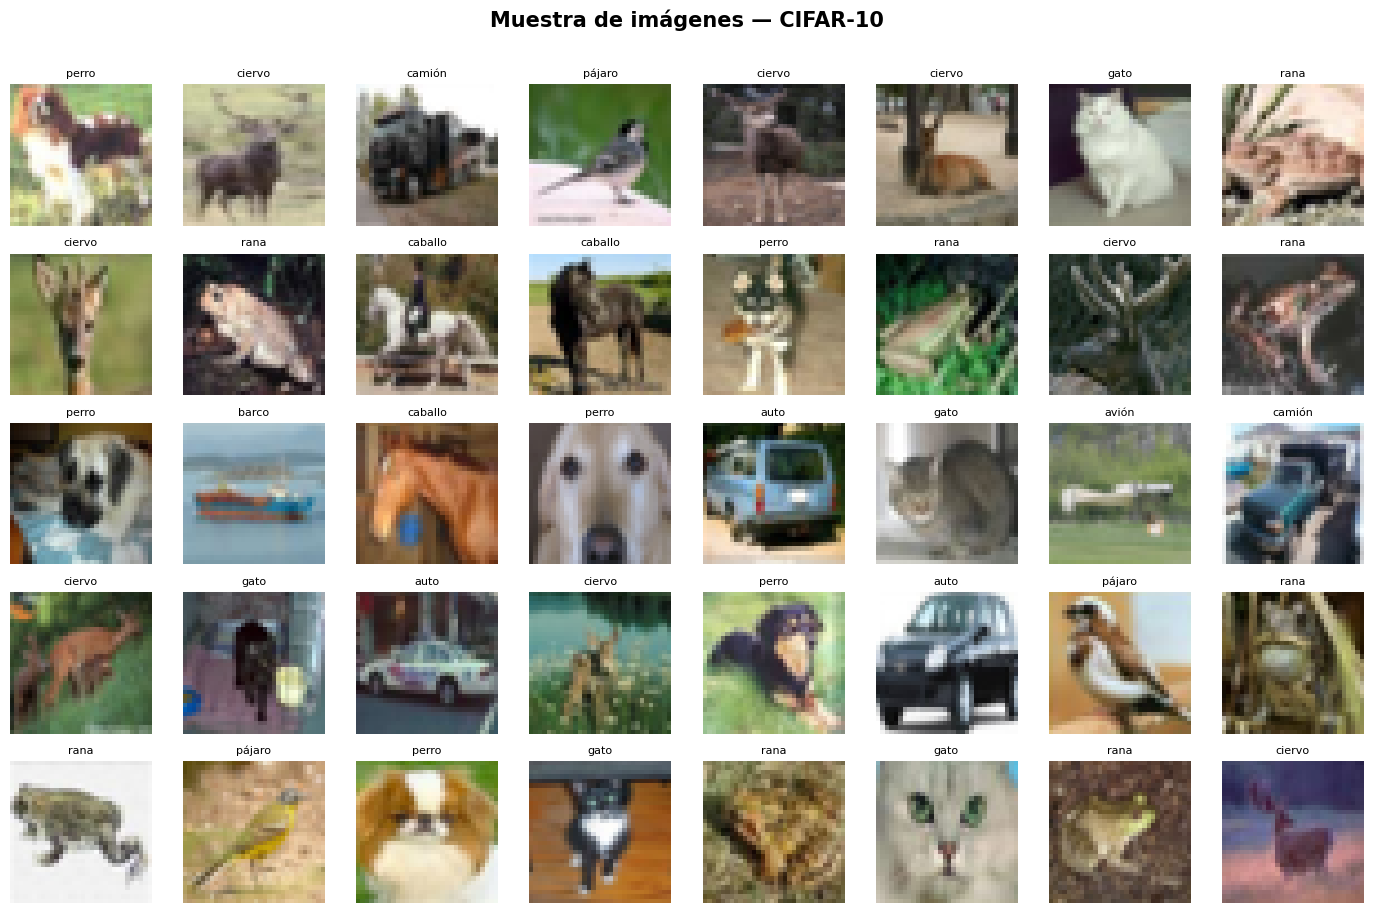

In [ ]:
def desnormalizar(tensor_imagen):
    """Invierte la normalización para poder visualizar la imagen."""
    return tensor_imagen * 0.5 + 0.5   # regresa al rango [0, 1]

# Tomamos un batch del loader y seleccionamos las primeras 40 imágenes
imagenes_muestra, etiquetas_muestra = next(iter(train_loader))
imagenes_muestra = imagenes_muestra[:40]
etiquetas_muestra = etiquetas_muestra[:40]

fig, ejes = plt.subplots(5, 8, figsize=(14, 9))
fig.suptitle("Muestra de imágenes — CIFAR-10", fontsize=15, fontweight="bold", y=1.01)

for i, eje in enumerate(ejes.flat):
    img = desnormalizar(imagenes_muestra[i])   # des-normalizar
    img = img.permute(1, 2, 0).numpy()         # (C, H, W) → (H, W, C) para matplotlib
    img = img.clip(0, 1)                       # asegurar rango válido

    eje.imshow(img)
    eje.set_title(clases[etiquetas_muestra[i].item()], fontsize=8)
    eje.axis("off")   # ocultar ejes

plt.tight_layout()
plt.show()

## 3. ARQUITECTURA DE LA RED

Feedforward (también llamada MLP – Perceptrón Multicapa):

  Entrada (3072)  →  Capa Oculta 1 (512)  →  Capa Oculta 2 (256)  →  Salida (10)

ReLU: función de activación que "apaga" valores negativos → max(0, x)
Las imágenes se aplanan (flatten) antes de entrar a la red.

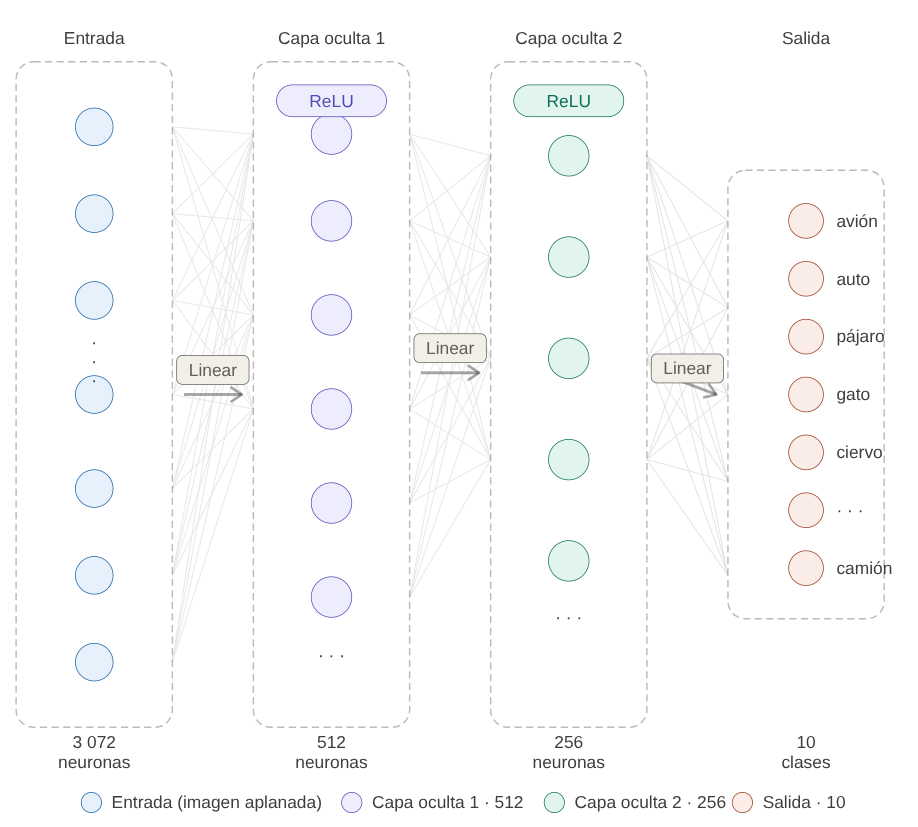


In [ ]:
class RedFeedForward(nn.Module):
    def __init__(self):
        super().__init__()

        self.red = nn.Sequential(
            # Capa de entrada → primera capa oculta
            nn.Linear(3072, 512),   # 3072 = 3 canales × 32 × 32 píxeles
            nn.ReLU(),

            # Primera capa oculta → segunda capa oculta
            nn.Linear(512, 256),
            nn.ReLU(),

            # Segunda capa oculta → capa de salida (10 clases)
            nn.Linear(256, 10)
            # No aplicamos Softmax aquí: CrossEntropyLoss lo incluye internamente
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Aplanar: (batch, 3, 32, 32) → (batch, 3072)
        return self.red(x)


modelo = RedFeedForward().to(dispositivo)
print("\nArquitectura de la red:")
print(modelo)


Arquitectura de la red:
RedFeedForward(
  (red): Sequential(
    (0): Linear(in_features=3072, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


##  4. FUNCIÓN DE PÉRDIDA Y OPTIMIZADOR
CrossEntropyLoss: ideal para clasificación multiclase.
Adam: optimizador adaptativo, muy popular y fácil de usar.


In [ ]:
criterio   = nn.CrossEntropyLoss()
optimizador = optim.Adam(modelo.parameters(), lr=TASA_APREN)

## 5. ENTRENAMIENTO

In [ ]:
historial_perdida_train = []
historial_perdida_val   = []

print("\n Entrenando...\n")

for epoca in range(1, EPOCAS + 1):

    # — Fase de entrenamiento —
    modelo.train()
    perdida_total = 0.0

    for imagenes, etiquetas in train_loader:
        imagenes = imagenes.to(dispositivo)
        etiquetas = etiquetas.to(dispositivo)

        optimizador.zero_grad()          # 1) Limpiar gradientes anteriores
        salidas = modelo(imagenes)       # 2) Paso hacia adelante (forward)
        perdida = criterio(salidas, etiquetas)  # 3) Calcular pérdida
        perdida.backward()              # 4) Retropropagación (backward)
        optimizador.step()              # 5) Actualizar pesos

        perdida_total += perdida.item()

    perdida_train = perdida_total / len(train_loader)

    # — Fase de validación —
    modelo.eval()
    perdida_val_total = 0.0

    with torch.no_grad():  # No necesitamos gradientes en validación
        for imagenes, etiquetas in test_loader:
            imagenes  = imagenes.to(dispositivo)
            etiquetas = etiquetas.to(dispositivo)
            salidas   = modelo(imagenes)
            perdida_val_total += criterio(salidas, etiquetas).item()

    perdida_val = perdida_val_total / len(test_loader)

    historial_perdida_train.append(perdida_train)
    historial_perdida_val.append(perdida_val)

    print(f"Época {epoca:2d}/{EPOCAS}  |  "
          f"Pérdida entrenamiento: {perdida_train:.4f}  |  "
          f"Pérdida validación: {perdida_val:.4f}")


 Entrenando...

Época  1/15  |  Pérdida entrenamiento: 1.6281  |  Pérdida validación: 1.4763
Época  2/15  |  Pérdida entrenamiento: 1.4073  |  Pérdida validación: 1.4605
Época  3/15  |  Pérdida entrenamiento: 1.2918  |  Pérdida validación: 1.3596
Época  4/15  |  Pérdida entrenamiento: 1.2002  |  Pérdida validación: 1.3637
Época  5/15  |  Pérdida entrenamiento: 1.1135  |  Pérdida validación: 1.3513
Época  6/15  |  Pérdida entrenamiento: 1.0293  |  Pérdida validación: 1.3686
Época  7/15  |  Pérdida entrenamiento: 0.9564  |  Pérdida validación: 1.4295
Época  8/15  |  Pérdida entrenamiento: 0.8758  |  Pérdida validación: 1.4522
Época  9/15  |  Pérdida entrenamiento: 0.7987  |  Pérdida validación: 1.4723
Época 10/15  |  Pérdida entrenamiento: 0.7296  |  Pérdida validación: 1.5408
Época 11/15  |  Pérdida entrenamiento: 0.6625  |  Pérdida validación: 1.6669
Época 12/15  |  Pérdida entrenamiento: 0.5965  |  Pérdida validación: 1.7248
Época 13/15  |  Pérdida entrenamiento: 0.5434  |  Pérdida v

## 6. EVALUACIÓN FINAL

In [ ]:
modelo.eval()
correctos = 0
total     = 0

with torch.no_grad():
    for imagenes, etiquetas in test_loader:
        imagenes  = imagenes.to(dispositivo)
        etiquetas = etiquetas.to(dispositivo)
        salidas   = modelo(imagenes)
        _, predicciones = torch.max(salidas, 1)  # Clase con mayor probabilidad
        correctos += (predicciones == etiquetas).sum().item()
        total     += etiquetas.size(0)

precision = 100 * correctos / total
print(f"\nPrecisión final en el conjunto de prueba: {precision:.2f}%")


Precisión final en el conjunto de prueba: 53.38%


## 7. GRÁFICOS

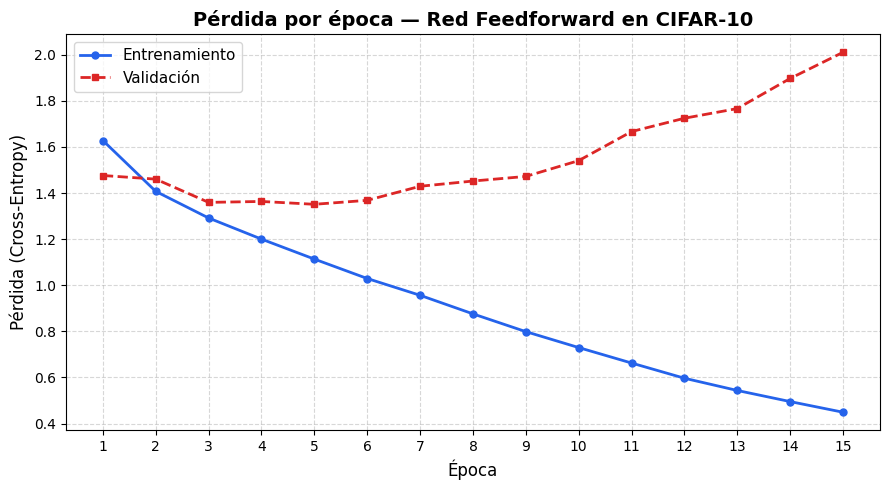


Gráfico guardado como 'perdida_por_epoca.png'


In [ ]:
epocas_eje = range(1, EPOCAS + 1)

plt.figure(figsize=(9, 5))
plt.plot(epocas_eje, historial_perdida_train, "o-", color="#2563EB",
         linewidth=2, markersize=5, label="Entrenamiento")
plt.plot(epocas_eje, historial_perdida_val,   "s--", color="#DC2626",
         linewidth=2, markersize=5, label="Validación")

plt.title("Pérdida por época — Red Feedforward en CIFAR-10", fontsize=14, fontweight="bold")
plt.xlabel("Época", fontsize=12)
plt.ylabel("Pérdida (Cross-Entropy)", fontsize=12)
plt.xticks(epocas_eje)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("perdida_por_epoca.png", dpi=150)
plt.show()

Responda las siguientes preguntas

1. ¿Qué relación observa entre la curva de pérdida de entrenamiento (*training loss*) y la pérdida de validación/generalización (*validation loss*)?
2. Basándose en las métricas obtenidas, ¿considera que la red presenta señales de sobreajuste (overfitting), subajuste (underfitting) o un ajuste óptimo?
3. ¿Qué cree que se podría hacer para mejorar la clasificación y la capacidad de generalización del modelo?